# Import Libraries

In [ ]:
!pip install codecarbon
!pip install ptflops

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import os

from einops import rearrange
from torchvision import datasets
from torchvision import transforms
from torch.utils.data.sampler import SubsetRandomSampler
from torch.utils.data import DataLoader, ConcatDataset
import torch.optim as optim

import numpy as np
from torch.cuda.amp import autocast, GradScaler
from tqdm import tqdm

import seaborn as sns
from collections import defaultdict
#from codecarbon import EmissionsTracker
import time

import pandas as pd
import gc
import time
import os
import matplotlib.pyplot as plt
import ast
from collections import Counter

import cv2
from skimage.color import rgb2gray
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
from skimage.filters import sobel, laplace
from scipy import fftpack, stats
from scipy.stats import entropy as shannon_entropy
from skimage.measure import label, regionprops

from sklearn.preprocessing import MinMaxScaler
import pickle
import pandas as pd

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Dataloaders

In [ ]:
def data_loader(data_dir,
                batch_size,
                random_seed=42,
                valid_size=0.1,
                shuffle=True,
                test=False):

    normalize = transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std=[0.2023, 0.1994, 0.2010],
    )

    # Images Regularization
    transform_original = transforms.Compose([
        transforms.Resize((256,256)),
        transforms.ToTensor(),
        normalize,
    ])

    # Image Augmentation
    transform_aug = transforms.Compose([
        transforms.RandomResizedCrop(256, scale=(0.8,1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2,
                               saturation=0.2, hue=0.1),
        transforms.ToTensor(),
        normalize,
        transforms.RandomErasing(p=0.1)
    ])

    if test:
        dataset = datasets.CIFAR10(
            root=data_dir, train=False,
            download=True, transform=transform_original
        )

        return DataLoader(
            dataset, batch_size=batch_size, shuffle=shuffle
        )

    # Regular Dataset
    train_dataset_orig = datasets.CIFAR10(
        root=data_dir, train=True, download=True, transform=transform_original
    )

    # Augmented Dataset
    train_dataset_aug = datasets.CIFAR10(
        root=data_dir, train=True, download=True, transform=transform_aug
    )


    # Unify the training sets and separate their data from the validation set
    num_train = len(train_dataset_orig)
    indices = list(range(num_train))
    split = int(np.floor(valid_size * num_train))

    if shuffle:
        np.random.seed(random_seed)
        np.random.shuffle(indices)

    train_idx, valid_idx = indices[split:], indices[:split]


    train_dataset = ConcatDataset([
        torch.utils.data.Subset(train_dataset_orig, train_idx),
        torch.utils.data.Subset(train_dataset_aug, train_idx)
    ])

    train_loader = DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True, num_workers=4
    )

    valid_dataset = torch.utils.data.Subset(train_dataset_orig, valid_idx)
    valid_loader = DataLoader(
        valid_dataset, batch_size=1, shuffle=False, num_workers=4
    )

    return train_loader, valid_loader

In [ ]:
train_loader, valid_loader = data_loader(data_dir='./data',
                                             batch_size=64)
test_loader = data_loader(data_dir='./data',
                                  batch_size=1,
                                  test=True)

100%|██████████| 170M/170M [00:13<00:00, 12.3MB/s]


# Backbone Implementation

In [ ]:
def conv_1x1_bn(inp, oup):
    return nn.Sequential(
        nn.Conv2d(inp, oup, 1, 1, 0, bias=False),
        nn.BatchNorm2d(oup),
        nn.SiLU()
    )


def conv_nxn_bn(inp, oup, kernal_size=3, stride=1):
    return nn.Sequential(
        nn.Conv2d(inp, oup, kernal_size, stride, 1, bias=False),
        nn.BatchNorm2d(oup),
        nn.SiLU()
    )


class PreNorm(nn.Module):
    def __init__(self, dim, fn):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.fn = fn

    def forward(self, x, **kwargs):
        return self.fn(self.norm(x), **kwargs)


class FeedForward(nn.Module):
    def __init__(self, dim, hidden_dim, dropout=0.):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.net(x)


class Attention(nn.Module):
    def __init__(self, dim, heads=8, dim_head=64, dropout=0.):
        super().__init__()
        inner_dim = dim_head *  heads
        project_out = not (heads == 1 and dim_head == dim)

        self.heads = heads
        self.scale = dim_head ** -0.5

        self.attend = nn.Softmax(dim = -1)
        self.to_qkv = nn.Linear(dim, inner_dim * 3, bias = False)

        self.to_out = nn.Sequential(
            nn.Linear(inner_dim, dim),
            nn.Dropout(dropout)
        ) if project_out else nn.Identity()

    def forward(self, x):
        qkv = self.to_qkv(x).chunk(3, dim=-1)
        q, k, v = map(lambda t: rearrange(t, 'b p n (h d) -> b p h n d', h = self.heads), qkv)

        dots = torch.matmul(q, k.transpose(-1, -2)) * self.scale
        attn = self.attend(dots)
        out = torch.matmul(attn, v)
        out = rearrange(out, 'b p h n d -> b p n (h d)')
        return self.to_out(out)


class Transformer(nn.Module):
    def __init__(self, dim, depth, heads, dim_head, mlp_dim, dropout=0.):
        super().__init__()
        self.layers = nn.ModuleList([])
        for _ in range(depth):
            self.layers.append(nn.ModuleList([
                PreNorm(dim, Attention(dim, heads, dim_head, dropout)),
                PreNorm(dim, FeedForward(dim, mlp_dim, dropout))
            ]))

    def forward(self, x):
        for attn, ff in self.layers:
            x = attn(x) + x
            x = ff(x) + x
        return x


class MV2Block(nn.Module):
    def __init__(self, inp, oup, stride=1, expansion=4):
        super().__init__()
        self.stride = stride
        assert stride in [1, 2]

        hidden_dim = int(inp * expansion)
        self.use_res_connect = self.stride == 1 and inp == oup

        if expansion == 1:
            self.conv = nn.Sequential(
                # dw
                nn.Conv2d(hidden_dim, hidden_dim, 3, stride, 1, groups=hidden_dim, bias=False),
                nn.BatchNorm2d(hidden_dim),
                nn.SiLU(),
                # pw-linear
                nn.Conv2d(hidden_dim, oup, 1, 1, 0, bias=False),
                nn.BatchNorm2d(oup),
            )
        else:
            self.conv = nn.Sequential(
                # pw
                nn.Conv2d(inp, hidden_dim, 1, 1, 0, bias=False),
                nn.BatchNorm2d(hidden_dim),
                nn.SiLU(),
                # dw
                nn.Conv2d(hidden_dim, hidden_dim, 3, stride, 1, groups=hidden_dim, bias=False),
                nn.BatchNorm2d(hidden_dim),
                nn.SiLU(),
                # pw-linear
                nn.Conv2d(hidden_dim, oup, 1, 1, 0, bias=False),
                nn.BatchNorm2d(oup),
            )

    def forward(self, x):
        if self.use_res_connect:
            return x + self.conv(x)
        else:
            return self.conv(x)


class MobileViTBlock(nn.Module):
    def __init__(self, dim, depth, channel, kernel_size, patch_size, mlp_dim, dropout=0.):
        super().__init__()
        self.ph, self.pw = patch_size

        self.conv1 = conv_nxn_bn(channel, channel, kernel_size)
        self.conv2 = conv_1x1_bn(channel, dim)

        self.transformer = Transformer(dim, depth, 4, 8, mlp_dim, dropout)

        self.conv3 = conv_1x1_bn(dim, channel)
        self.conv4 = conv_nxn_bn(2 * channel, channel, kernel_size)

    def forward(self, x):
        y = x.clone()

        # Local representations
        x = self.conv1(x)
        x = self.conv2(x)

        # Global representations
        _, _, h, w = x.shape
        x = rearrange(x, 'b d (h ph) (w pw) -> b (ph pw) (h w) d', ph=self.ph, pw=self.pw)
        x = self.transformer(x)
        x = rearrange(x, 'b (ph pw) (h w) d -> b d (h ph) (w pw)', h=h//self.ph, w=w//self.pw, ph=self.ph, pw=self.pw)

        # Fusion
        x = self.conv3(x)
        x = torch.cat((x, y), 1)
        x = self.conv4(x)
        return x


class MobileViT(nn.Module):
    def __init__(self, image_size, dims, channels, num_classes, expansion=4, kernel_size=3, patch_size=(2, 2)):
        super().__init__()
        ih, iw = image_size
        ph, pw = patch_size
        assert ih % ph == 0 and iw % pw == 0

        L = [2, 4, 3]

        self.conv1 = conv_nxn_bn(3, channels[0], stride=2)

        self.mv2 = nn.ModuleList([])
        self.mv2.append(MV2Block(channels[0], channels[1], 1, expansion))
        self.mv2.append(MV2Block(channels[1], channels[2], 2, expansion))
        self.mv2.append(MV2Block(channels[2], channels[3], 1, expansion))
        self.mv2.append(MV2Block(channels[2], channels[3], 1, expansion))
        self.mv2.append(MV2Block(channels[3], channels[4], 2, expansion))
        self.mv2.append(MV2Block(channels[5], channels[6], 2, expansion))
        self.mv2.append(MV2Block(channels[7], channels[8], 2, expansion))

        self.mvit = nn.ModuleList([])
        self.mvit.append(MobileViTBlock(dims[0], L[0], channels[5], kernel_size, patch_size, int(dims[0]*2)))
        self.mvit.append(MobileViTBlock(dims[1], L[1], channels[7], kernel_size, patch_size, int(dims[1]*4)))
        self.mvit.append(MobileViTBlock(dims[2], L[2], channels[9], kernel_size, patch_size, int(dims[2]*4)))

        self.conv2 = conv_1x1_bn(channels[-2], channels[-1])

        self.pool = nn.AvgPool2d(ih//32, 1)
        self.fc = nn.Linear(channels[-1], num_classes, bias=False)

    def forward(self, x):
        x = self.conv1(x)
        x = self.mv2[0](x)

        x = self.mv2[1](x)
        x = self.mv2[2](x)
        x = self.mv2[3](x)

        x = self.mv2[4](x)
        x = self.mvit[0](x)

        x = self.mv2[5](x)
        x = self.mvit[1](x)

        x = self.mv2[6](x)
        x = self.mvit[2](x)
        x = self.conv2(x)

        x = self.pool(x).view(-1, x.shape[1])
        x = self.fc(x)
        return x


def mobilevit_xxs():
    dims = [64, 80, 96]
    channels = [16, 16, 24, 24, 48, 48, 64, 64, 80, 80, 320]
    return MobileViT((256, 256), dims, channels, num_classes=10, expansion=2)

# EE Implementation

In [ ]:
class EarlyExitHead(nn.Module):
    def __init__(self, in_channels, num_classes):
        super().__init__()
        self.exit = nn.Sequential(
            nn.Conv2d(in_channels, in_channels // 2, kernel_size=1, bias=False),
            nn.BatchNorm2d(in_channels // 2),
            nn.SiLU(),
            nn.AdaptiveAvgPool2d(1)
        )
        self.fc = nn.Linear(in_channels // 2, num_classes)

    def forward(self, x):
        x = self.exit(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

In [ ]:
class MobileViTWithEarlyExits(nn.Module):
    def __init__(self, base_model, exit_points=['mvit_0', 'mvit_1'], num_classes=10, exit_threshold=0.9):
        super().__init__()
        self.base = base_model
        self.exit_threshold = exit_threshold
        self.num_classes = num_classes

        self.exit_channels = {
            'mvit_0': base_model.mvit[0].conv4[0].out_channels,
            'mvit_1': base_model.mvit[1].conv4[0].out_channels
        }

        self.exits = nn.ModuleDict({
            name: EarlyExitHead(self.exit_channels[name], num_classes)
            for name in exit_points
        })

    def forward(self, x, targets=None, train_mode=True):
        losses = []

        x = self.base.conv1(x)
        x = self.base.mv2[0](x)
        x = self.base.mv2[1](x)
        x = self.base.mv2[2](x)
        x = self.base.mv2[3](x)
        x = self.base.mv2[4](x)

        x = self.base.mvit[0](x)
        if 'mvit_0' in self.exits:
            out = self.exits['mvit_0'](x)
            if train_mode:
                losses.append(out)
            else:
                conf, pred = F.softmax(out, dim=1).max(dim=1)
                if conf.mean() > self.exit_threshold:
                    return 0, pred

        x = self.base.mv2[5](x)
        x = self.base.mvit[1](x)
        if 'mvit_1' in self.exits:
            out = self.exits['mvit_1'](x)
            if train_mode:
                losses.append(out)
            else:
                conf, pred = F.softmax(out, dim=1).max(dim=1)
                if conf.mean() > self.exit_threshold:
                    return 1, pred

        x = self.base.mv2[6](x)
        x = self.base.mvit[2](x)
        x = self.base.conv2(x)
        x = self.base.pool(x).view(-1, x.shape[1])
        out = self.base.fc(x)

        if train_mode:
            losses.append(out)
            return losses
        else:
            _, pred = F.softmax(out, dim=1).max(dim=1)
            return len(self.exits), pred

In [ ]:
class Gmodel(nn.Module):

  def __init__(self, hidden_dim):
        super(Gmodel, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()
        )

  def forward(self, x):
        return self.net(x).squeeze(-1)

# Offline Phase

In [ ]:
def forward_teacher(model, images, device='cuda'):
    x = images
    x = model.base.conv1(x)
    x = model.base.mv2[0](x)
    x = model.base.mv2[1](x)
    x = model.base.mv2[2](x)
    x = model.base.mv2[3](x)
    x = model.base.mv2[4](x)
    x_mvit0 = model.base.mvit[0](x)
    x = model.base.mv2[5](x_mvit0)
    x_mvit1 = model.base.mvit[1](x)
    x = model.base.mv2[6](x_mvit1)
    x = model.base.mvit[2](x)
    x = model.base.conv2(x)
    x = model.base.pool(x).view(-1, x.shape[1])
    final = model.base.fc(x)
    return final, x_mvit0, x_mvit1

In [ ]:
def compute_weighted_kd_loss(model, images, labels, exit_weights=[0.3, 0.5, 1.0], T=3.0, alpha=0.3, device='cuda'):

    losses = []
    outs = []

    final_logits, x_mvit0, x_mvit1 = forward_teacher(model, images, device)


    if 'mvit_0' in model.exits:
        student_logits = model.exits['mvit_0'](x_mvit0)
        outs.append(student_logits)
        ce_loss = F.cross_entropy(student_logits, labels)
        p = F.log_softmax(student_logits / T, dim=1)
        q = F.softmax(final_logits / T, dim=1)
        kl_loss = F.kl_div(p, q, reduction='batchmean') * (T*T)
        losses.append(exit_weights[0] * (alpha * ce_loss + (1-alpha) * kl_loss))

    # ---- Early exit 1 ----
    if 'mvit_1' in model.exits:
        student_logits = model.exits['mvit_1'](x_mvit1)
        outs.append(student_logits)
        ce_loss = F.cross_entropy(student_logits, labels)
        p = F.log_softmax(student_logits / T, dim=1)
        q = F.softmax(final_logits / T, dim=1)
        kl_loss = F.kl_div(p, q, reduction='batchmean') * (T*T)
        losses.append(exit_weights[1] * (alpha * ce_loss + (1-alpha) * kl_loss))

    # ---- Final classifier ----
    ce_loss = F.cross_entropy(final_logits, labels)
    losses.append(exit_weights[-1] * ce_loss)

    # Total weighted loss
    outs.append(final_logits)
    return losses, outs


In [ ]:
pretrained_model = mobilevit_xxs()
pretrained_model.load_state_dict(torch.load("/content/mobileViT_xxs_10.pth"))

<All keys matched successfully>

In [ ]:
model = MobileViTWithEarlyExits(pretrained_model, exit_points=['mvit_0', 'mvit_1'], num_classes=10)

In [ ]:
from tqdm import tqdm

def train_with_exits(model, train_loader, valid_loader, device):
    gating_model = Gmodel(hidden_dim=10).to(device)
    global_eval = [torch.tensor(0.0, device=device) for _ in range(4)]
    global_count = [torch.tensor(0.0, device=device) for _ in range(4)]

    global_coverage_eval = [torch.tensor(0.0, device=device) for _ in range(4)]
    global_coverage_count = [torch.tensor(0.0, device=device) for _ in range(4)]

    scaler = torch.cuda.amp.GradScaler()


    # Exit-only warmup

    #for param in model.base.parameters():
    #    param.requires_grad = False  # freeze backbone

    optimizer = torch.optim.AdamW(list(model.parameters()) + list(gating_model.parameters()), lr=5e-4, weight_decay=0.05)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)
    criterion = torch.nn.CrossEntropyLoss()

    num_epochs = 20
    best_val_loss = float('inf')
    patience = 7
    epochs_no_improve = 0
    exit_weights = [0.9, 0.7, 0.5]

    print("\n=== Phase 1: Training early exits only (frozen backbone) ===")
    for epoch in range(num_epochs):
        model.to(device)
        model.train()
        running_loss = 0.0

        for images, labels in tqdm(train_loader, desc=f"Phase1 Epoch {epoch+1}/{num_epochs}"):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            with torch.cuda.amp.autocast():
              outputs = model(images)

              losses = [criterion(o, labels) for o in outputs]
              pen = [gating_model(o).mean() for o in outputs]
              first_term = losses

              second_term = []

              c_term = [0, 0, 0, 0]
              phi_term = []

              for idx, o in enumerate(outputs):

                check = gating_model(o) >= 0.5
                global_eval[idx] += check.sum()
                global_count[idx] += check.numel()

                phi_term.append(global_eval[idx] / global_count[idx])

                if epoch > 1:
                  pred = torch.argmax(o, dim=1)
                  hit = (pred == labels).sum()

                  global_coverage_eval[idx] += hit
                  global_coverage_count[idx] += labels.numel()

                  c_term[idx] = global_coverage_eval[idx] / global_coverage_count[idx]

            second_term = [l*d + (max(0, c-g)**2) for l, d, c, g in zip(first_term, pen, c_term, phi_term)]

            denominator = [1, 2, 3]

            total_loss = sum([(a+b)*c for a,b,c in zip(first_term, second_term, denominator)])
            denominator_sum = sum(denominator)
            total_loss = total_loss / denominator_sum

            scaler.scale(total_loss).backward()
            scaler.step(optimizer)
            scaler.update()

        print(f"[Phase1] Epoch {epoch+1}: Train Loss={total_loss:.4f}")

        scheduler.step()

    torch.save(model.state_dict(), "mobilevit_xxs_phase1_inverse.pth")
    torch.save(gating_model.state_dict(), "gating_phase1_inverse.pth")

    print("Training complete")

# Online Phase

In [ ]:
class UCB1:

    def __init__(self, arms):

        self.arms = arms
        self.n_arms = len(arms)
        self.arm_to_index = {arm: idx for idx, arm in enumerate(arms)}
        self.index_to_arm = {idx: arm for idx, arm in enumerate(arms)}

        self.counts = np.zeros(self.n_arms)
        self.values = np.zeros(self.n_arms)
        self.total_steps = 0

    def select_arm(self):
        self.total_steps += 1
        ucb_values = np.zeros(self.n_arms)

        for i in range(self.n_arms):
            if self.counts[i] == 0:
                return self.index_to_arm[i]
            average_reward = self.values[i]
            confidence = np.sqrt((2 * np.log(self.total_steps)) / self.counts[i])
            ucb_values[i] = average_reward + confidence

        selected_index = np.argmax(ucb_values)
        return self.index_to_arm[selected_index]

    def update(self, arm, reward):
        index = self.arm_to_index[arm]
        self.counts[index] += 1
        n = self.counts[index]
        value = self.values[index]
        self.values[index] += (reward - value) / n

In [ ]:
from scipy.stats import norm


class BayesUCB:

    def __init__(self, arms, mu0=0.0, lambda0=1e-6, alpha0=1.0, beta0=1.0, alpha_quant=1.0):
        self.arms = arms
        self.n_arms = len(arms)

        # Priors
        self.mu0 = mu0
        self.lambda0 = lambda0
        self.alpha0 = alpha0
        self.beta0 = beta0

        self.alpha_quant = alpha_quant

        self.counts = np.zeros(self.n_arms)
        self.sum_rewards = np.zeros(self.n_arms)
        self.sum_sq_rewards = np.zeros(self.n_arms)

        self.total_steps = 0

        self.arm_to_index = {arm: i for i, arm in enumerate(arms)}
        self.index_to_arm = {i: arm for i, arm in enumerate(arms)}


    def _posterior_params(self, i):
        n = self.counts[i]
        S = self.sum_rewards[i]
        Sq = self.sum_sq_rewards[i]

        lambda_n = self.lambda0 + n
        mu_n = (self.lambda0 * self.mu0 + S) / lambda_n

        alpha_n = self.alpha0 + 0.5 * n
        beta_n = self.beta0 + 0.5 * (Sq + self.lambda0 * self.mu0**2 - lambda_n * mu_n**2)

        return mu_n, lambda_n, alpha_n, beta_n


    def select_arm(self):
        self.total_steps += 1

        q_t = self._quantile()
        z = norm.ppf(q_t)

        ucb_values = np.zeros(self.n_arms)

        for i in range(self.n_arms):
            if self.counts[i] == 0:
                return self.index_to_arm[i]

            mu_n, lambda_n, alpha_n, beta_n = self._posterior_params(i)

            sigma_post = np.sqrt(beta_n / ((alpha_n - 1) * lambda_n))

            ucb_values[i] = mu_n + z * sigma_post

        selected_index = np.argmax(ucb_values)
        return self.index_to_arm[selected_index]


    def update(self, arm, reward):
        i = self.arm_to_index[arm]
        self.counts[i] += 1
        self.sum_rewards[i] += reward
        self.sum_sq_rewards[i] += reward * reward

    def _quantile(self):
      t = self.total_steps
      if t < 3:
        return 0.95
      return 1 - 1.0 / (t * (np.log(t) ** self.alpha_quant))

In [ ]:
class UCB_V:
    def __init__(self, arms, B=1.0):
        self.arms = arms
        self.n_arms = len(arms)
        self.arm_to_index = {arm: idx for idx, arm in enumerate(arms)}
        self.index_to_arm = {idx: arm for idx, arm in enumerate(arms)}

        self.counts = np.zeros(self.n_arms)
        self.values = np.zeros(self.n_arms)
        self.sum_sq_diff = np.zeros(self.n_arms)
        self.total_steps = 0
        self.B = B

        self.global_min_reward = np.inf
        self.global_max_reward = -np.inf

    def _scale_reward(self, reward):
        self.global_min_reward = min(self.global_min_reward, reward)
        self.global_max_reward = max(self.global_max_reward, reward)

        if self.global_max_reward == self.global_min_reward:
            return 0.5
        return (reward - self.global_min_reward) / (self.global_max_reward - self.global_min_reward)

    def select_arm(self):
        self.total_steps += 1
        ucb_values = np.zeros(self.n_arms)

        if np.any(self.counts == 0):
            return self.index_to_arm[np.argmin(self.counts)]

        log_t = np.log(self.total_steps)

        for i in range(self.n_arms):
            n_i = self.counts[i]
            mu_i = self.values[i]

            if n_i > 1:
                variance_i = self.sum_sq_diff[i] / (n_i)
            else:
                variance_i = 1e-9

            term1 = np.sqrt((2 * variance_i * log_t) / n_i)

            term2 = (3 * self.B * log_t) / n_i


            ucb_values[i] = mu_i + term1 + term2

        selected_index = np.argmax(ucb_values)
        return self.index_to_arm[selected_index]

    def update(self, arm, reward):

        index = self.arm_to_index[arm]
        self.counts[index] += 1
        n = self.counts[index]

        old_mean = self.values[index]

        self.values[index] += (reward - old_mean) / n

        new_mean = self.values[index]
        self.sum_sq_diff[index] += (reward - old_mean) * (reward - new_mean)

In [ ]:
class UCB_Tuned:

    def __init__(self, arms):
        self.arms = arms
        self.n_arms = len(arms)
        self.arm_to_index = {arm: idx for idx, arm in enumerate(arms)}
        self.index_to_arm = {idx: arm for idx, arm in enumerate(arms)}

        self.counts = np.zeros(self.n_arms)
        self.values = np.zeros(self.n_arms)
        self.sum_sq_rewards = np.zeros(self.n_arms)
        self.total_steps = 0

        self.global_min_reward = np.inf
        self.global_max_reward = -np.inf

    def _scale_reward(self, reward):
        self.global_min_reward = min(self.global_min_reward, reward)
        self.global_max_reward = max(self.global_max_reward, reward)

        if self.global_max_reward == self.global_min_reward:
            return 0.5
        return (reward - self.global_min_reward) / (self.global_max_reward - self.global_min_reward)

    def select_arm(self):
        self.total_steps += 1
        ucb_values = np.zeros(self.n_arms)

        if np.any(self.counts == 0):
            return self.index_to_arm[np.argmin(self.counts)]

        log_t = np.log(self.total_steps)

        for i in range(self.n_arms):
            n_i = self.counts[i]
            mu_i = self.values[i]

            V_i = (self.sum_sq_rewards[i] / n_i) - (mu_i ** 2)

            inner_term = V_i + np.sqrt((2 * log_t) / n_i)

            V_tilde = np.minimum(inner_term, 0.25)

            ucb_values[i] = mu_i + np.sqrt((log_t / n_i) * V_tilde)

        selected_index = np.argmax(ucb_values)
        return self.index_to_arm[selected_index]

    def update(self, arm, reward):

        index = self.arm_to_index[arm]
        self.counts[index] += 1
        n = self.counts[index]

        old_mean = self.values[index]
        self.values[index] += (reward - old_mean) / n

        self.sum_sq_rewards[index] += reward ** 2

In [ ]:
class UCB_BwK:

    def __init__(self, thresholds):
        self.arms = thresholds
        self.n_arms = len(thresholds)
        self.arm_to_index = {arm: idx for idx, arm in enumerate(thresholds)}
        self.index_to_arm = {idx: arm for idx, arm in enumerate(thresholds)}

        self.counts = np.zeros(self.n_arms)
        self.mu_rewards = np.zeros(self.n_arms)
        self.mu_costs = np.zeros(self.n_arms)
        self.total_steps = 0

    def select_arm(self):
        self.total_steps += 1
        ucb_ratio_values = np.zeros(self.n_arms)

        if np.any(self.counts == 0):
            return self.index_to_arm[np.argmin(self.counts)]

        log_t = np.log(self.total_steps)

        for i in range(self.n_arms):
            n_i = self.counts[i]

            confidence_ratio = np.sqrt((2 * log_t) / n_i)

            ucb_rew = self.mu_rewards[i] + confidence_ratio

            tau_t = np.sqrt(np.log(self.total_steps) / self.total_steps)
            ucb_cost = max(self.mu_costs[i] - confidence_ratio, tau_t)

            ucb_ratio_values[i] = ucb_rew / ucb_cost

        selected_index = np.argmax(ucb_ratio_values)
        return self.index_to_arm[selected_index]

    def update(self, arm, reward, actual_cost):
        index = self.arm_to_index[arm]
        self.counts[index] += 1
        n = self.counts[index]

        old_mu_reward = self.mu_rewards[index]
        self.mu_rewards[index] += (reward - old_mu_reward) / n

        old_mu_cost = self.mu_costs[index]
        self.mu_costs[index] += (actual_cost - old_mu_cost) / n

In [ ]:
device = "cuda"

gating1 = Gmodel(hidden_dim=10)
gating1.load_state_dict(torch.load("/content/gating_phase1_inverse.pth"))
gating1.to(device)

gating2 = Gmodel(hidden_dim=10)
gating2.load_state_dict(torch.load("/content/gating_phase2_inverse.pth"))
gating2.to(device)

registry = {1:gating1, 2:gating2}

In [ ]:
class MobileViTWithUCB(nn.Module):

    def __init__(self, base_model, exit_points=['mvit_0', 'mvit_1'], num_classes=10,
                 arms=[0.6, 0.65, 0.7, 0.75, 0.8, 0.85], bwk=False, mode=None):

        super().__init__()
        self.base = base_model
        self.num_classes = num_classes

        self.thresholds = arms
        self.mode = mode
        self.bwk = bwk
        self.gating=None

        if self.mode == "ucb1":
          self.ucb = UCB1(self.thresholds)
        if self.mode == "tuned":
          self.ucb = UCB_Tuned(self.thresholds)
        if self.mode == "bwk":
          self.ucb = UCB_BwK(self.thresholds)
        if self.mode == "v":
          self.ucb = UCB_V(self.thresholds)
        if self.mode == "bayes":
          self.ucb = BayesUCB(self.thresholds)

        self.current_tau = 0.0
        self.num_early_exits = len(exit_points)
        self.cost_per_exit = 0.0033

        self.exit_channels = {
            'mvit_0': base_model.mvit[0].conv4[0].out_channels,
            'mvit_1': base_model.mvit[1].conv4[0].out_channels
        }

        self.exits = nn.ModuleDict({
            name: EarlyExitHead(self.exit_channels[name], num_classes)
            for name in exit_points
        })

    def select_tau(self):
        self.current_tau = self.ucb.select_arm()
        return self.current_tau

    def update_ucb(self, logits, exit_idx):

        probs = F.softmax(logits, dim=1)
        conf, _ = probs.max(dim=1)
        pro = self.gating(logits)

        if self.bwk == True:
          reward = (conf * (1 - pro))
          self.ucb.update(self.current_tau, reward, (self.cost_per_exit * exit_idx))

        else:

          reward = (conf * (1 - pro)) - self.cost_per_exit * exit_idx
          self.ucb.update(self.current_tau, reward)

    def forward(self, x, targets=None, train_mode=True):
        losses = []

        x = self.base.conv1(x)
        x = self.base.mv2[0](x)
        x = self.base.mv2[1](x)
        x = self.base.mv2[2](x)
        x = self.base.mv2[3](x)
        x = self.base.mv2[4](x)

        if not train_mode:
            tau = self.select_tau()

        x = self.base.mvit[0](x)
        if 'mvit_0' in self.exits:
            out0 = self.exits['mvit_0'](x)

            if train_mode:
                losses.append(out0)
            else:
                prob = F.softmax(out0, dim=1)
                con, pred = prob.max(dim=1)

                if con >= tau:
                    self.update_ucb(out0, 0)
                    return 0, pred

        x = self.base.mv2[5](x)
        x = self.base.mvit[1](x)
        if 'mvit_1' in self.exits:
            out1 = self.exits['mvit_1'](x)

            if train_mode:
                losses.append(out1)
            else:
                prob = F.softmax(out1, dim=1)
                con, pred = prob.max(dim=1)
                if con >= tau:
                    self.update_ucb(out1, 1)
                    return 1, pred

        x = self.base.mv2[6](x)
        x = self.base.mvit[2](x)
        x = self.base.conv2(x)
        x = self.base.pool(x).view(-1, x.shape[1])
        out_final = self.base.fc(x)

        if train_mode:
            losses.append(out_final)
            return losses
        else:
            final_exit_idx = self.num_early_exits
            self.update_ucb(out_final, final_exit_idx)

            _, pred = F.softmax(out_final, dim=1).max(dim=1)
            return final_exit_idx, pred

# CIFAR10.1v6 Evaluation

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, datasets
from PIL import Image
import numpy as np

class NumpyDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = self.images[idx]
        label = self.labels[idx]

        # Convert from HWC uint8 to PIL Image
        from PIL import Image
        img = Image.fromarray(img)

        if self.transform:
            img = self.transform(img)

        return img, label

In [ ]:
import numpy as np
import os
import pathlib

def load_cifar10_1_colab(version_string='v6', data_dir='/content', load_tinyimage_indices=False):

    if version_string not in ['v4', 'v6', 'v7']:
        raise ValueError(f'Unknown dataset version "{version_string}".')

    filename = f'cifar10.1_{version_string}'
    label_filepath = os.path.join(data_dir, filename + '_labels.npy')
    imagedata_filepath = os.path.join(data_dir, filename + '_data.npy')

    print(f'Loading labels from file {label_filepath}')
    assert pathlib.Path(label_filepath).is_file(), f"{label_filepath} not found!"
    labels = np.load(label_filepath, allow_pickle=True)

    print(f'Loading image data from file {imagedata_filepath}')
    assert pathlib.Path(imagedata_filepath).is_file(), f"{imagedata_filepath} not found!"
    imagedata = np.load(imagedata_filepath, allow_pickle=True)

    # Basic sanity checks
    assert len(labels.shape) == 1
    assert len(imagedata.shape) == 4
    assert labels.shape[0] == imagedata.shape[0]
    assert imagedata.shape[1] == 32 and imagedata.shape[2] == 32 and imagedata.shape[3] == 3

    # Dataset size check
    if version_string in ['v6', 'v7']:
        assert labels.shape[0] == 2000
    elif version_string == 'v4':
        assert labels.shape[0] == 2021

    if not load_tinyimage_indices:
        return imagedata, labels
    else:
        import json
        ti_indices_filepath = os.path.join(data_dir, f'{filename}_ti_indices.json')
        print(f'Loading Tiny Image indices from file {ti_indices_filepath}')
        assert pathlib.Path(ti_indices_filepath).is_file(), f"{ti_indices_filepath} not found!"
        with open(ti_indices_filepath, 'r') as f:
            tinyimage_indices = json.load(f)
        assert isinstance(tinyimage_indices, list) and len(tinyimage_indices) == labels.shape[0]
        return imagedata, labels, tinyimage_indices

In [ ]:
images, labels = load_cifar10_1_colab(version_string='v6', data_dir='/content')
print(images.shape, labels.shape)

Loading labels from file /content/cifar10.1_v6_labels.npy
Loading image data from file /content/cifar10.1_v6_data.npy
(2000, 32, 32, 3) (2000,)


In [ ]:
normalize = transforms.Normalize(
    mean=[0.4914, 0.4822, 0.4465],
    std=[0.2023, 0.1994, 0.2010],
)

transform_original = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    normalize,
])

test_dataset = NumpyDataset(images, labels, transform=transform_original)

test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

for imgs, lbls in test_loader:
    print(imgs.shape, lbls.shape)
    break

torch.Size([1, 3, 256, 256]) torch.Size([1])


## UCB1

#### Load models

In [ ]:
bsline = mobilevit_xxs()
bsline.load_state_dict(torch.load("/content/mobileViT_xxs_10.pth"))

<All keys matched successfully>

In [ ]:
pretrained_model = mobilevit_xxs()
pretrained_model.load_state_dict(torch.load("/content/mobileViT_xxs_10.pth"))

model1 = MobileViTWithEarlyExits(base_model=pretrained_model, exit_points=['mvit_0', 'mvit_1'], num_classes=10)
model1.load_state_dict(torch.load("/content/mobilevit_xxs_phase1_10.pth"))

<All keys matched successfully>

#### UCB1 - Phase1

In [ ]:
model_arms1 = MobileViTWithUCB(base_model=pretrained_model, exit_points=['mvit_0', 'mvit_1'], num_classes=10, arms=[0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95], bwk=False, mode="ucb1")
model_arms1.load_state_dict(torch.load("/content/mobilevit_xxs_phase1_inverse.pth"), strict=False)
model_arms1.gating = registry[1]

In [ ]:
model_arms2 = MobileViTWithUCB(base_model=pretrained_model, exit_points=['mvit_0', 'mvit_1'], num_classes=10, arms=[0.45, 0.55, 0.65, 0.75, 0.85, 0.9, 0.95], bwk=False, mode="ucb1")
model_arms2.load_state_dict(torch.load("/content/mobilevit_xxs_phase1_inverse.pth"))
model_arms2.gating = registry[1]

In [ ]:
model_arms3 = MobileViTWithUCB(base_model=pretrained_model, exit_points=['mvit_0', 'mvit_1'], num_classes=10, arms=[0.7, 0.75, 0.8, 0.85, 0.9, 0.95], bwk=False, mode="ucb1")
model_arms3.load_state_dict(torch.load("/content/mobilevit_xxs_phase1_inverse.pth"))
model_arms3.gating = registry[1]

In [ ]:
model_arms4 = MobileViTWithUCB(base_model=pretrained_model, exit_points=['mvit_0', 'mvit_1'], num_classes=10, arms=[0.45, 0.5, 0.55, 0.6, 0.65, 0.7], bwk=False, mode="ucb1")
model_arms4.load_state_dict(torch.load("/content/mobilevit_xxs_phase1_inverse.pth"))
model_arms4.gating = registry[1]

In [ ]:
model_arms5 = MobileViTWithUCB(base_model=pretrained_model, exit_points=['mvit_0', 'mvit_1'], num_classes=10, arms=[0.8, 0.85, 0.9, 0.95], bwk=False, mode="ucb1")
model_arms5.load_state_dict(torch.load("/content/mobilevit_xxs_phase1_inverse.pth"))
model_arms5.gating = registry[1]

In [ ]:
model_arms6 = MobileViTWithUCB(base_model=pretrained_model, exit_points=['mvit_0', 'mvit_1'], num_classes=10, arms=[0.5, 0.6, 0.7, 0.8, 0.9, 0.95], bwk=False, mode="ucb1")
model_arms6.load_state_dict(torch.load("/content/mobilevit_xxs_phase1_inverse.pth"))
model_arms6.gating = registry[1]

#### Concat

In [ ]:
all = {
    'mvit_10':bsline,
    'phase1':model1,
    'arms1_UCB1':model_arms1,
    'arms2_UCB1':model_arms2,
    'arms3_UCB1':model_arms3,
    'arms4_UCB1':model_arms4,
    'arms5_UCB1':model_arms5,
    'arms6_UCB1':model_arms6
}

In [ ]:
def evaluate_model(model, model_name, test_loader, early=False):
    device = 'cuda'
    model.eval()
    model.to(device)

    correct = 0
    total = 0
    NUM_EXITS = 3
    exit_counts = [0] * NUM_EXITS if early else None

    start_time = time.time()
    tracker = EmissionsTracker(measure_power_secs=1)
    tracker.start()

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            if early:
                exit_id, preds = model(images, train_mode=False)
                exit_counts[exit_id] += 1
            else:
                preds = model(images)
                conf, preds = F.softmax(preds, dim=1).max(dim=1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

    tracker.stop()
    end_time = time.time()

    accuracy = 100 * correct / total
    inference_time = end_time - start_time

    data = tracker._prepare_emissions_data()
    energy = data.energy_consumed

    result = {
        "model_name": model_name,
        "accuracy": accuracy,
        "inference_time_sec": inference_time,
        "energy_kWh": energy,
    }

    for i in range(3):
        if early:
            result[f"exit_{i}_count"] = exit_counts[i]
        else:
            result[f"exit_{i}_count"] = float('nan')

    return result

def extract_data(models, test_loader):

  all_results = []

  for name, model in models.items():
    print(name)
    if name == 'mvit_10':
      res = evaluate_model(model, name, test_loader, early=False)
    else:
      res = evaluate_model(model, name, test_loader, early=True)

    all_results.append(res)

  df = pd.DataFrame(all_results)

  return df

In [ ]:
data = extract_data(all, test_loader)

[codecarbon WARNING @ 07:02:11] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 07:02:11] [setup] RAM Tracking...
[codecarbon INFO @ 07:02:11] [setup] CPU Tracking...


mvit_10


[codecarbon WARNING @ 07:02:12] We saw that you have a Intel(R) Xeon(R) CPU @ 2.20GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 07:02:12] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 07:02:12] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.20GHz
[codecarbon WARNING @ 07:02:12] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 07:02:12] [setup] GPU Tracking...
[codecarbon INFO @ 07:02:12] Tracking Nvidia GPU via pynvml
[codecarbon INFO @ 07:02:12] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: global constant
                GPU Tracking Method: pynvml
            
[codecarbon INFO @ 07:02:12] >>> Tracker's metadata:
[codecarbon INFO @ 07:02

phase1


[codecarbon WARNING @ 07:02:39] We saw that you have a Intel(R) Xeon(R) CPU @ 2.20GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 07:02:39] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 07:02:39] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.20GHz
[codecarbon WARNING @ 07:02:39] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 07:02:39] [setup] GPU Tracking...
[codecarbon INFO @ 07:02:39] Tracking Nvidia GPU via pynvml
[codecarbon INFO @ 07:02:39] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: global constant
                GPU Tracking Method: pynvml
            
[codecarbon INFO @ 07:02:39] >>> Tracker's metadata:
[codecarbon INFO @ 07:02

...

[codecarbon WARNING @ 07:06:21] We saw that you have a Intel(R) Xeon(R) CPU @ 2.20GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 07:06:21] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 07:06:21] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.20GHz
[codecarbon WARNING @ 07:06:21] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 07:06:21] [setup] GPU Tracking...
[codecarbon INFO @ 07:06:21] Tracking Nvidia GPU via pynvml
[codecarbon INFO @ 07:06:21] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: global constant
                GPU Tracking Method: pynvml
            
[codecarbon INFO @ 07:06:21] >>> Tracker's metadata:
[codecarbon INFO @ 07:06

ph2_arms5_UCB1


[codecarbon WARNING @ 07:06:37] We saw that you have a Intel(R) Xeon(R) CPU @ 2.20GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 07:06:37] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 07:06:37] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.20GHz
[codecarbon WARNING @ 07:06:37] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 07:06:37] [setup] GPU Tracking...
[codecarbon INFO @ 07:06:37] Tracking Nvidia GPU via pynvml
[codecarbon INFO @ 07:06:37] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: global constant
                GPU Tracking Method: pynvml
            
[codecarbon INFO @ 07:06:37] >>> Tracker's metadata:
[codecarbon INFO @ 07:06

ph2_arms6_UCB1


[codecarbon WARNING @ 07:06:59] We saw that you have a Intel(R) Xeon(R) CPU @ 2.20GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 07:06:59] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 07:06:59] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.20GHz
[codecarbon WARNING @ 07:06:59] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 07:06:59] [setup] GPU Tracking...
[codecarbon INFO @ 07:06:59] Tracking Nvidia GPU via pynvml
[codecarbon INFO @ 07:06:59] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: global constant
                GPU Tracking Method: pynvml
            
[codecarbon INFO @ 07:06:59] >>> Tracker's metadata:
[codecarbon INFO @ 07:06

In [ ]:
data.to_csv('ucb1_mvit10_results.csv')

## UCB Bayes

#### Load models

In [ ]:
bsline = mobilevit_xxs()
bsline.load_state_dict(torch.load("/content/mobileViT_xxs_10.pth"))

<All keys matched successfully>

In [ ]:
pretrained_model = mobilevit_xxs()
pretrained_model.load_state_dict(torch.load("/content/mobileViT_xxs_10.pth"))

model1 = MobileViTWithEarlyExits(base_model=pretrained_model, exit_points=['mvit_0', 'mvit_1'], num_classes=10)
model1.load_state_dict(torch.load("/content/mobilevit_xxs_phase1_10.pth"))

<All keys matched successfully>

#### UCB Bayes - Phase1

In [ ]:
model_arms1 = MobileViTWithUCB(base_model=pretrained_model, exit_points=['mvit_0', 'mvit_1'], num_classes=10, arms=[0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95], bwk=False, mode="bayes")
model_arms1.load_state_dict(torch.load("/content/mobilevit_xxs_phase1_inverse.pth"), strict=False)
model_arms1.gating = registry[1]

In [ ]:
model_arms2 = MobileViTWithUCB(base_model=pretrained_model, exit_points=['mvit_0', 'mvit_1'], num_classes=10, arms=[0.45, 0.55, 0.65, 0.75, 0.85, 0.9, 0.95], bwk=False, mode="bayes")
model_arms2.load_state_dict(torch.load("/content/mobilevit_xxs_phase1_inverse.pth"))
model_arms2.gating = registry[1]

In [ ]:
model_arms3 = MobileViTWithUCB(base_model=pretrained_model, exit_points=['mvit_0', 'mvit_1'], num_classes=10, arms=[0.7, 0.75, 0.8, 0.85, 0.9, 0.95], bwk=False, mode="bayes")
model_arms3.load_state_dict(torch.load("/content/mobilevit_xxs_phase1_inverse.pth"))
model_arms3.gating = registry[1]

In [ ]:
model_arms4 = MobileViTWithUCB(base_model=pretrained_model, exit_points=['mvit_0', 'mvit_1'], num_classes=10, arms=[0.45, 0.5, 0.55, 0.6, 0.65, 0.7], bwk=False, mode="bayes")
model_arms4.load_state_dict(torch.load("/content/mobilevit_xxs_phase1_inverse.pth"))
model_arms4.gating = registry[1]

In [ ]:
model_arms5 = MobileViTWithUCB(base_model=pretrained_model, exit_points=['mvit_0', 'mvit_1'], num_classes=10, arms=[0.8, 0.85, 0.9, 0.95], bwk=False, mode="bayes")
model_arms5.load_state_dict(torch.load("/content/mobilevit_xxs_phase1_inverse.pth"))
model_arms5.gating = registry[1]

In [ ]:
model_arms6 = MobileViTWithUCB(base_model=pretrained_model, exit_points=['mvit_0', 'mvit_1'], num_classes=10, arms=[0.5, 0.6, 0.7, 0.8, 0.9, 0.95], bwk=False, mode="bayes")
model_arms6.load_state_dict(torch.load("/content/mobilevit_xxs_phase1_inverse.pth"))
model_arms6.gating = registry[1]

#### Concat

In [ ]:
all = {
    'mvit_10':bsline,
    'phase1':model1,
    'arms1_UCB1':model_arms1,
    'arms2_UCB1':model_arms2,
    'arms3_UCB1':model_arms3,
    'arms4_UCB1':model_arms4,
    'arms5_UCB1':model_arms5,
    'arms6_UCB1':model_arms6
}

In [ ]:
data = extract_data(all, test_loader)

[codecarbon WARNING @ 07:07:18] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 07:07:18] [setup] RAM Tracking...
[codecarbon INFO @ 07:07:18] [setup] CPU Tracking...


mvit_10


[codecarbon WARNING @ 07:07:19] We saw that you have a Intel(R) Xeon(R) CPU @ 2.20GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 07:07:19] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 07:07:19] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.20GHz
[codecarbon WARNING @ 07:07:19] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 07:07:19] [setup] GPU Tracking...
[codecarbon INFO @ 07:07:19] Tracking Nvidia GPU via pynvml
[codecarbon INFO @ 07:07:19] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: global constant
                GPU Tracking Method: pynvml
            
[codecarbon INFO @ 07:07:19] >>> Tracker's metadata:
[codecarbon INFO @ 07:07

phase1


[codecarbon WARNING @ 07:07:45] We saw that you have a Intel(R) Xeon(R) CPU @ 2.20GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 07:07:45] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 07:07:45] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.20GHz
[codecarbon WARNING @ 07:07:45] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 07:07:45] [setup] GPU Tracking...
[codecarbon INFO @ 07:07:45] Tracking Nvidia GPU via pynvml
[codecarbon INFO @ 07:07:45] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: global constant
                GPU Tracking Method: pynvml
            
[codecarbon INFO @ 07:07:45] >>> Tracker's metadata:
[codecarbon INFO @ 07:07

...

[codecarbon WARNING @ 07:11:35] We saw that you have a Intel(R) Xeon(R) CPU @ 2.20GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 07:11:35] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 07:11:35] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.20GHz
[codecarbon WARNING @ 07:11:35] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 07:11:35] [setup] GPU Tracking...
[codecarbon INFO @ 07:11:35] Tracking Nvidia GPU via pynvml
[codecarbon INFO @ 07:11:35] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: global constant
                GPU Tracking Method: pynvml
            
[codecarbon INFO @ 07:11:35] >>> Tracker's metadata:
[codecarbon INFO @ 07:11

ph2_arms5_UCB1


[codecarbon WARNING @ 07:11:52] We saw that you have a Intel(R) Xeon(R) CPU @ 2.20GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 07:11:52] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 07:11:52] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.20GHz
[codecarbon WARNING @ 07:11:52] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 07:11:52] [setup] GPU Tracking...
[codecarbon INFO @ 07:11:52] Tracking Nvidia GPU via pynvml
[codecarbon INFO @ 07:11:52] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: global constant
                GPU Tracking Method: pynvml
            
[codecarbon INFO @ 07:11:52] >>> Tracker's metadata:
[codecarbon INFO @ 07:11

ph2_arms6_UCB1


[codecarbon WARNING @ 07:12:15] We saw that you have a Intel(R) Xeon(R) CPU @ 2.20GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 07:12:15] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 07:12:15] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.20GHz
[codecarbon WARNING @ 07:12:15] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 07:12:15] [setup] GPU Tracking...
[codecarbon INFO @ 07:12:15] Tracking Nvidia GPU via pynvml
[codecarbon INFO @ 07:12:15] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: global constant
                GPU Tracking Method: pynvml
            
[codecarbon INFO @ 07:12:15] >>> Tracker's metadata:
[codecarbon INFO @ 07:12

In [ ]:
data.to_csv('ucb_bayes_mvit10_results.csv')

## UCB Tuned

#### Load models

In [ ]:
bsline = mobilevit_xxs()
bsline.load_state_dict(torch.load("/content/mobileViT_xxs_10.pth"))

<All keys matched successfully>

In [ ]:
pretrained_model = mobilevit_xxs()
pretrained_model.load_state_dict(torch.load("/content/mobileViT_xxs_10.pth"))

model1 = MobileViTWithEarlyExits(base_model=pretrained_model, exit_points=['mvit_0', 'mvit_1'], num_classes=10)
model1.load_state_dict(torch.load("/content/mobilevit_xxs_phase1_10.pth"))

<All keys matched successfully>

#### UCB Tuned - Phase1

In [ ]:
model_arms1 = MobileViTWithUCB(base_model=pretrained_model, exit_points=['mvit_0', 'mvit_1'], num_classes=10, arms=[0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95], bwk=False, mode="tuned")
model_arms1.load_state_dict(torch.load("/content/mobilevit_xxs_phase1_inverse.pth"), strict=False)
model_arms1.gating = registry[1]

In [ ]:
model_arms2 = MobileViTWithUCB(base_model=pretrained_model, exit_points=['mvit_0', 'mvit_1'], num_classes=10, arms=[0.45, 0.55, 0.65, 0.75, 0.85, 0.9, 0.95], bwk=False, mode="tuned")
model_arms2.load_state_dict(torch.load("/content/mobilevit_xxs_phase1_inverse.pth"))
model_arms2.gating = registry[1]

In [ ]:
model_arms3 = MobileViTWithUCB(base_model=pretrained_model, exit_points=['mvit_0', 'mvit_1'], num_classes=10, arms=[0.7, 0.75, 0.8, 0.85, 0.9, 0.95], bwk=False, mode="tuned")
model_arms3.load_state_dict(torch.load("/content/mobilevit_xxs_phase1_inverse.pth"))
model_arms3.gating = registry[1]

In [ ]:
model_arms4 = MobileViTWithUCB(base_model=pretrained_model, exit_points=['mvit_0', 'mvit_1'], num_classes=10, arms=[0.45, 0.5, 0.55, 0.6, 0.65, 0.7], bwk=False, mode="tuned")
model_arms4.load_state_dict(torch.load("/content/mobilevit_xxs_phase1_inverse.pth"))
model_arms4.gating = registry[1]

In [ ]:
model_arms5 = MobileViTWithUCB(base_model=pretrained_model, exit_points=['mvit_0', 'mvit_1'], num_classes=10, arms=[0.8, 0.85, 0.9, 0.95], bwk=False, mode="tuned")
model_arms5.load_state_dict(torch.load("/content/mobilevit_xxs_phase1_inverse.pth"))
model_arms5.gating = registry[1]

In [ ]:
model_arms6 = MobileViTWithUCB(base_model=pretrained_model, exit_points=['mvit_0', 'mvit_1'], num_classes=10, arms=[0.5, 0.6, 0.7, 0.8, 0.9, 0.95], bwk=False, mode="tuned")
model_arms6.load_state_dict(torch.load("/content/mobilevit_xxs_phase1_inverse.pth"))
model_arms6.gating = registry[1]

#### Concat

In [ ]:
all = {
    'mvit_10':bsline,
    'phase1':model1,
    'arms1_UCB1':model_arms1,
    'arms2_UCB1':model_arms2,
    'arms3_UCB1':model_arms3,
    'arms4_UCB1':model_arms4,
    'arms5_UCB1':model_arms5,
    'arms6_UCB1':model_arms6
}

In [ ]:
data = extract_data(all, test_loader)

[codecarbon WARNING @ 06:17:23] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 06:17:23] [setup] RAM Tracking...
[codecarbon INFO @ 06:17:23] [setup] CPU Tracking...


mvit_10


[codecarbon WARNING @ 06:17:24] We saw that you have a Intel(R) Xeon(R) CPU @ 2.20GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 06:17:24] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 06:17:24] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.20GHz
[codecarbon WARNING @ 06:17:24] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 06:17:24] [setup] GPU Tracking...
[codecarbon INFO @ 06:17:24] Tracking Nvidia GPU via pynvml
[codecarbon INFO @ 06:17:24] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: global constant
                GPU Tracking Method: pynvml
            
[codecarbon INFO @ 06:17:24] >>> Tracker's metadata:
[codecarbon INFO @ 06:17

phase1


[codecarbon WARNING @ 06:17:53] Unable to access geographical location through primary API. Will resort to using the backup API - Exception : HTTPSConnectionPool(host='get.geojs.io', port=443): Read timed out. (read timeout=0.5) - url=https://get.geojs.io/v1/ip/geo.json
[codecarbon WARNING @ 06:17:54] Unable to access geographical location. Using 'Canada' as the default value - Exception : HTTPSConnectionPool(host='ip-api.com', port=443): Read timed out. (read timeout=0.5) - url=https://get.geojs.io/v1/ip/geo.json
[codecarbon INFO @ 06:17:54] Emissions data (if any) will be saved to file /content/emissions.csv
[codecarbon INFO @ 06:17:55] Energy consumed for RAM : 0.000006 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 06:17:55] Delta energy consumed for CPU with constant : 0.000012 kWh, power : 42.5 W
[codecarbon INFO @ 06:17:55] Energy consumed for All CPU : 0.000012 kWh
[codecarbon INFO @ 06:17:55] Energy consumed for all GPUs : 0.000009 kWh. Total GPU Power : 33.10097106946349 W
[codec

...

[codecarbon WARNING @ 06:21:42] Unable to access geographical location through primary API. Will resort to using the backup API - Exception : HTTPSConnectionPool(host='get.geojs.io', port=443): Read timed out. (read timeout=0.5) - url=https://get.geojs.io/v1/ip/geo.json
[codecarbon WARNING @ 06:21:42] Unable to access geographical location. Using 'Canada' as the default value - Exception : 'country' - url=https://get.geojs.io/v1/ip/geo.json
[codecarbon INFO @ 06:21:42] Emissions data (if any) will be saved to file /content/emissions.csv
[codecarbon INFO @ 06:21:43] Energy consumed for RAM : 0.000006 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 06:21:43] Delta energy consumed for CPU with constant : 0.000012 kWh, power : 42.5 W
[codecarbon INFO @ 06:21:43] Energy consumed for All CPU : 0.000012 kWh
[codecarbon INFO @ 06:21:43] Energy consumed for all GPUs : 0.000011 kWh. Total GPU Power : 38.049173527204466 W
[codecarbon INFO @ 06:21:43] 0.000028 kWh of electricity and 0.000000 L of water

ph2_arms5_UCB1


[codecarbon WARNING @ 06:21:59] Unable to access geographical location through primary API. Will resort to using the backup API - Exception : HTTPSConnectionPool(host='get.geojs.io', port=443): Read timed out. (read timeout=0.5) - url=https://get.geojs.io/v1/ip/geo.json
[codecarbon WARNING @ 06:22:00] Unable to access geographical location. Using 'Canada' as the default value - Exception : HTTPSConnectionPool(host='ip-api.com', port=443): Read timed out. (read timeout=0.5) - url=https://get.geojs.io/v1/ip/geo.json
[codecarbon INFO @ 06:22:00] Emissions data (if any) will be saved to file /content/emissions.csv
[codecarbon INFO @ 06:22:01] Energy consumed for RAM : 0.000006 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 06:22:01] Delta energy consumed for CPU with constant : 0.000012 kWh, power : 42.5 W
[codecarbon INFO @ 06:22:01] Energy consumed for All CPU : 0.000012 kWh
[codecarbon INFO @ 06:22:01] Energy consumed for all GPUs : 0.000011 kWh. Total GPU Power : 38.33429748230216 W
[codec

ph2_arms6_UCB1


[codecarbon WARNING @ 06:22:21] Unable to access geographical location through primary API. Will resort to using the backup API - Exception : HTTPSConnectionPool(host='get.geojs.io', port=443): Read timed out. (read timeout=0.5) - url=https://get.geojs.io/v1/ip/geo.json
[codecarbon WARNING @ 06:22:22] Unable to access geographical location. Using 'Canada' as the default value - Exception : 'country' - url=https://get.geojs.io/v1/ip/geo.json
[codecarbon INFO @ 06:22:22] Emissions data (if any) will be saved to file /content/emissions.csv
[codecarbon INFO @ 06:22:23] Energy consumed for RAM : 0.000006 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 06:22:23] Delta energy consumed for CPU with constant : 0.000012 kWh, power : 42.5 W
[codecarbon INFO @ 06:22:23] Energy consumed for All CPU : 0.000012 kWh
[codecarbon INFO @ 06:22:23] Energy consumed for all GPUs : 0.000011 kWh. Total GPU Power : 38.59660072614553 W
[codecarbon INFO @ 06:22:23] 0.000028 kWh of electricity and 0.000000 L of water 

In [ ]:
data.to_csv('ucb_tuned_mvit10_results.csv')

## UCB V

#### Load models

In [ ]:
bsline = mobilevit_xxs()
bsline.load_state_dict(torch.load("/content/mobileViT_xxs_10.pth"))

<All keys matched successfully>

In [ ]:
pretrained_model = mobilevit_xxs()
pretrained_model.load_state_dict(torch.load("/content/mobileViT_xxs_10.pth"))

model1 = MobileViTWithEarlyExits(base_model=pretrained_model, exit_points=['mvit_0', 'mvit_1'], num_classes=10)
model1.load_state_dict(torch.load("/content/mobilevit_xxs_phase1_10.pth"))

<All keys matched successfully>

#### UCB V - Phase1

In [ ]:
model_arms1 = MobileViTWithUCB(base_model=pretrained_model, exit_points=['mvit_0', 'mvit_1'], num_classes=10, arms=[0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95], bwk=False, mode="v")
model_arms1.load_state_dict(torch.load("/content/mobilevit_xxs_phase1_inverse.pth"), strict=False)
model_arms1.gating = registry[1]

In [ ]:
model_arms2 = MobileViTWithUCB(base_model=pretrained_model, exit_points=['mvit_0', 'mvit_1'], num_classes=10, arms=[0.45, 0.55, 0.65, 0.75, 0.85, 0.9, 0.95], bwk=False, mode="v")
model_arms2.load_state_dict(torch.load("/content/mobilevit_xxs_phase1_inverse.pth"))
model_arms2.gating = registry[1]

In [ ]:
model_arms3 = MobileViTWithUCB(base_model=pretrained_model, exit_points=['mvit_0', 'mvit_1'], num_classes=10, arms=[0.7, 0.75, 0.8, 0.85, 0.9, 0.95], bwk=False, mode="v")
model_arms3.load_state_dict(torch.load("/content/mobilevit_xxs_phase1_inverse.pth"))
model_arms3.gating = registry[1]

In [ ]:
model_arms4 = MobileViTWithUCB(base_model=pretrained_model, exit_points=['mvit_0', 'mvit_1'], num_classes=10, arms=[0.45, 0.5, 0.55, 0.6, 0.65, 0.7], bwk=False, mode="v")
model_arms4.load_state_dict(torch.load("/content/mobilevit_xxs_phase1_inverse.pth"))
model_arms4.gating = registry[1]

In [ ]:
model_arms5 = MobileViTWithUCB(base_model=pretrained_model, exit_points=['mvit_0', 'mvit_1'], num_classes=10, arms=[0.8, 0.85, 0.9, 0.95], bwk=False, mode="v")
model_arms5.load_state_dict(torch.load("/content/mobilevit_xxs_phase1_inverse.pth"))
model_arms5.gating = registry[1]

In [ ]:
model_arms6 = MobileViTWithUCB(base_model=pretrained_model, exit_points=['mvit_0', 'mvit_1'], num_classes=10, arms=[0.5, 0.6, 0.7, 0.8, 0.9, 0.95], bwk=False, mode="v")
model_arms6.load_state_dict(torch.load("/content/mobilevit_xxs_phase1_inverse.pth"))
model_arms6.gating = registry[1]

#### Concat

In [ ]:
all = {
    'mvit_10':bsline,
    'phase1':model1,
    'arms1_UCB1':model_arms1,
    'arms2_UCB1':model_arms2,
    'arms3_UCB1':model_arms3,
    'arms4_UCB1':model_arms4,
    'arms5_UCB1':model_arms5,
    'arms6_UCB1':model_arms6
}

In [ ]:
data = extract_data(all, test_loader)

[codecarbon WARNING @ 06:22:42] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 06:22:42] [setup] RAM Tracking...
[codecarbon INFO @ 06:22:42] [setup] CPU Tracking...
[codecarbon WARNING @ 06:22:42] We saw that you have a Intel(R) Xeon(R) CPU @ 2.20GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 06:22:42] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 06:22:42] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.20GHz
[codecarbon WARNING @ 06:22:42] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 06:22:42] [setup] GPU Tracking...
[codecarbon INFO @ 06:22:42] Tracking Nvidia GPU via pynvml
[codecarbon INFO @ 06:22:42] The below tracking methods have been set up:
                RAM Tracking Method: RAM po

mvit_10


[codecarbon WARNING @ 06:22:42] Unable to access geographical location through primary API. Will resort to using the backup API - Exception : HTTPSConnectionPool(host='get.geojs.io', port=443): Read timed out. (read timeout=0.5) - url=https://get.geojs.io/v1/ip/geo.json
[codecarbon WARNING @ 06:22:43] Unable to access geographical location. Using 'Canada' as the default value - Exception : HTTPSConnectionPool(host='ip-api.com', port=443): Read timed out. (read timeout=0.5) - url=https://get.geojs.io/v1/ip/geo.json
[codecarbon INFO @ 06:22:43] Emissions data (if any) will be saved to file /content/emissions.csv
[codecarbon INFO @ 06:22:44] Energy consumed for RAM : 0.000006 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 06:22:44] Delta energy consumed for CPU with constant : 0.000012 kWh, power : 42.5 W
[codecarbon INFO @ 06:22:44] Energy consumed for All CPU : 0.000012 kWh
[codecarbon INFO @ 06:22:44] Energy consumed for all GPUs : 0.000011 kWh. Total GPU Power : 39.11059517464955 W
[codec

phase1


[codecarbon WARNING @ 06:23:09] Unable to access geographical location through primary API. Will resort to using the backup API - Exception : HTTPSConnectionPool(host='get.geojs.io', port=443): Read timed out. (read timeout=0.5) - url=https://get.geojs.io/v1/ip/geo.json
[codecarbon WARNING @ 06:23:09] Unable to access geographical location. Using 'Canada' as the default value - Exception : HTTPSConnectionPool(host='ip-api.com', port=443): Read timed out. (read timeout=0.5) - url=https://get.geojs.io/v1/ip/geo.json
[codecarbon INFO @ 06:23:09] Emissions data (if any) will be saved to file /content/emissions.csv
[codecarbon INFO @ 06:23:10] Energy consumed for RAM : 0.000006 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 06:23:10] Delta energy consumed for CPU with constant : 0.000012 kWh, power : 42.5 W
[codecarbon INFO @ 06:23:10] Energy consumed for All CPU : 0.000012 kWh
[codecarbon INFO @ 06:23:10] Energy consumed for all GPUs : 0.000011 kWh. Total GPU Power : 39.44124501687573 W
[codec

...

[codecarbon WARNING @ 06:26:55] Unable to access geographical location through primary API. Will resort to using the backup API - Exception : HTTPSConnectionPool(host='get.geojs.io', port=443): Read timed out. (read timeout=0.5) - url=https://get.geojs.io/v1/ip/geo.json
[codecarbon WARNING @ 06:26:55] Unable to access geographical location. Using 'Canada' as the default value - Exception : HTTPSConnectionPool(host='ip-api.com', port=443): Read timed out. (read timeout=0.5) - url=https://get.geojs.io/v1/ip/geo.json
[codecarbon INFO @ 06:26:55] Emissions data (if any) will be saved to file /content/emissions.csv
[codecarbon INFO @ 06:26:56] Energy consumed for RAM : 0.000006 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 06:26:56] Delta energy consumed for CPU with constant : 0.000012 kWh, power : 42.5 W
[codecarbon INFO @ 06:26:56] Energy consumed for All CPU : 0.000012 kWh
[codecarbon INFO @ 06:26:56] Energy consumed for all GPUs : 0.000011 kWh. Total GPU Power : 40.71615204738846 W
[codec

ph2_arms5_UCB1


[codecarbon INFO @ 06:27:12] Emissions data (if any) will be saved to file /content/emissions.csv
[codecarbon INFO @ 06:27:13] Energy consumed for RAM : 0.000006 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 06:27:13] Delta energy consumed for CPU with constant : 0.000012 kWh, power : 42.5 W
[codecarbon INFO @ 06:27:13] Energy consumed for All CPU : 0.000012 kWh
[codecarbon INFO @ 06:27:13] Energy consumed for all GPUs : 0.000011 kWh. Total GPU Power : 40.352541175643594 W
[codecarbon INFO @ 06:27:13] 0.000029 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 06:27:14] Energy consumed for RAM : 0.000011 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 06:27:14] Delta energy consumed for CPU with constant : 0.000012 kWh, power : 42.5 W
[codecarbon INFO @ 06:27:14] Energy consumed for All CPU : 0.000024 kWh
[codecarbon INFO @ 06:27:14] Energy consumed for all GPUs : 0.000023 kWh. Total GPU Power : 40.992586613376766 W
[codecarbon INFO @ 06:27:14] 0.00005

ph2_arms6_UCB1


[codecarbon WARNING @ 06:27:33] Unable to access geographical location through primary API. Will resort to using the backup API - Exception : HTTPSConnectionPool(host='get.geojs.io', port=443): Read timed out. (read timeout=0.5) - url=https://get.geojs.io/v1/ip/geo.json
[codecarbon WARNING @ 06:27:34] Unable to access geographical location. Using 'Canada' as the default value - Exception : HTTPSConnectionPool(host='ip-api.com', port=443): Read timed out. (read timeout=0.5) - url=https://get.geojs.io/v1/ip/geo.json
[codecarbon INFO @ 06:27:34] Emissions data (if any) will be saved to file /content/emissions.csv
[codecarbon INFO @ 06:27:35] Energy consumed for RAM : 0.000006 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 06:27:35] Delta energy consumed for CPU with constant : 0.000012 kWh, power : 42.5 W
[codecarbon INFO @ 06:27:35] Energy consumed for All CPU : 0.000012 kWh
[codecarbon INFO @ 06:27:35] Energy consumed for all GPUs : 0.000011 kWh. Total GPU Power : 40.803770505354066 W
[code

In [ ]:
data.to_csv('ucb_v_mvit10_results.csv')

## UCB BwK

#### Load models

In [ ]:
bsline = mobilevit_xxs()
bsline.load_state_dict(torch.load("/content/mobileViT_xxs_10.pth"))

<All keys matched successfully>

In [ ]:
pretrained_model = mobilevit_xxs()
pretrained_model.load_state_dict(torch.load("/content/mobileViT_xxs_10.pth"))

model1 = MobileViTWithEarlyExits(base_model=pretrained_model, exit_points=['mvit_0', 'mvit_1'], num_classes=10)
model1.load_state_dict(torch.load("/content/mobilevit_xxs_phase1_10.pth"))

<All keys matched successfully>

#### UCB BwK - Phase1

In [ ]:
model_arms1 = MobileViTWithUCB(base_model=pretrained_model, exit_points=['mvit_0', 'mvit_1'], num_classes=10, arms=[0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95], bwk=True, mode="bwk")
model_arms1.load_state_dict(torch.load("/content/mobilevit_xxs_phase1_inverse.pth"), strict=False)
model_arms1.gating = registry[1]

In [ ]:
model_arms2 = MobileViTWithUCB(base_model=pretrained_model, exit_points=['mvit_0', 'mvit_1'], num_classes=10, arms=[0.45, 0.55, 0.65, 0.75, 0.85, 0.9, 0.95], bwk=True, mode="bwk")
model_arms2.load_state_dict(torch.load("/content/mobilevit_xxs_phase1_inverse.pth"))
model_arms2.gating = registry[1]

In [ ]:
model_arms3 = MobileViTWithUCB(base_model=pretrained_model, exit_points=['mvit_0', 'mvit_1'], num_classes=10, arms=[0.7, 0.75, 0.8, 0.85, 0.9, 0.95], bwk=True, mode="bwk")
model_arms3.load_state_dict(torch.load("/content/mobilevit_xxs_phase1_inverse.pth"))
model_arms3.gating = registry[1]

In [ ]:
model_arms4 = MobileViTWithUCB(base_model=pretrained_model, exit_points=['mvit_0', 'mvit_1'], num_classes=10, arms=[0.45, 0.5, 0.55, 0.6, 0.65, 0.7], bwk=True, mode="bwk")
model_arms4.load_state_dict(torch.load("/content/mobilevit_xxs_phase1_inverse.pth"))
model_arms4.gating = registry[1]

In [ ]:
model_arms5 = MobileViTWithUCB(base_model=pretrained_model, exit_points=['mvit_0', 'mvit_1'], num_classes=10, arms=[0.8, 0.85, 0.9, 0.95], bwk=True, mode="bwk")
model_arms5.load_state_dict(torch.load("/content/mobilevit_xxs_phase1_inverse.pth"))
model_arms5.gating = registry[1]

In [ ]:
model_arms6 = MobileViTWithUCB(base_model=pretrained_model, exit_points=['mvit_0', 'mvit_1'], num_classes=10, arms=[0.5, 0.6, 0.7, 0.8, 0.9, 0.95], bwk=True, mode="bwk")
model_arms6.load_state_dict(torch.load("/content/mobilevit_xxs_phase1_inverse.pth"))
model_arms6.gating = registry[1]

#### Concat

In [ ]:
all = {
    'mvit_10':bsline,
    'phase1':model1,
    'arms1_UCB1':model_arms1,
    'arms2_UCB1':model_arms2,
    'arms3_UCB1':model_arms3,
    'arms4_UCB1':model_arms4,
    'arms5_UCB1':model_arms5,
    'arms6_UCB1':model_arms6
}

In [ ]:
data = extract_data(all, test_loader)

[codecarbon WARNING @ 10:39:14] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 10:39:14] [setup] RAM Tracking...
[codecarbon INFO @ 10:39:14] [setup] CPU Tracking...


mvit_10


[codecarbon WARNING @ 10:39:15] We saw that you have a Intel(R) Xeon(R) CPU @ 2.20GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 10:39:15] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 10:39:15] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.20GHz
[codecarbon WARNING @ 10:39:15] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 10:39:15] [setup] GPU Tracking...
[codecarbon INFO @ 10:39:15] Tracking Nvidia GPU via pynvml
[codecarbon INFO @ 10:39:15] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: global constant
                GPU Tracking Method: pynvml
            
[codecarbon INFO @ 10:39:15] >>> Tracker's metadata:
[codecarbon INFO @ 10:39

phase1


[codecarbon WARNING @ 10:39:42] We saw that you have a Intel(R) Xeon(R) CPU @ 2.20GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 10:39:42] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 10:39:42] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.20GHz
[codecarbon WARNING @ 10:39:42] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 10:39:42] [setup] GPU Tracking...
[codecarbon INFO @ 10:39:42] Tracking Nvidia GPU via pynvml
[codecarbon INFO @ 10:39:42] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: global constant
                GPU Tracking Method: pynvml
            
[codecarbon INFO @ 10:39:42] >>> Tracker's metadata:
[codecarbon INFO @ 10:39

...

[codecarbon WARNING @ 10:43:17] We saw that you have a Intel(R) Xeon(R) CPU @ 2.20GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 10:43:17] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 10:43:17] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.20GHz
[codecarbon WARNING @ 10:43:17] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 10:43:17] [setup] GPU Tracking...
[codecarbon INFO @ 10:43:17] Tracking Nvidia GPU via pynvml
[codecarbon INFO @ 10:43:17] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: global constant
                GPU Tracking Method: pynvml
            
[codecarbon INFO @ 10:43:17] >>> Tracker's metadata:
[codecarbon INFO @ 10:43

ph2_arms5_UCB1


[codecarbon WARNING @ 10:43:33] We saw that you have a Intel(R) Xeon(R) CPU @ 2.20GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 10:43:33] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 10:43:33] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.20GHz
[codecarbon WARNING @ 10:43:33] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 10:43:33] [setup] GPU Tracking...
[codecarbon INFO @ 10:43:33] Tracking Nvidia GPU via pynvml
[codecarbon INFO @ 10:43:33] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: global constant
                GPU Tracking Method: pynvml
            
[codecarbon INFO @ 10:43:33] >>> Tracker's metadata:
[codecarbon INFO @ 10:43

ph2_arms6_UCB1


[codecarbon WARNING @ 10:43:54] We saw that you have a Intel(R) Xeon(R) CPU @ 2.20GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 10:43:54] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 10:43:54] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.20GHz
[codecarbon WARNING @ 10:43:54] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 10:43:54] [setup] GPU Tracking...
[codecarbon INFO @ 10:43:54] Tracking Nvidia GPU via pynvml
[codecarbon INFO @ 10:43:54] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: global constant
                GPU Tracking Method: pynvml
            
[codecarbon INFO @ 10:43:54] >>> Tracker's metadata:
[codecarbon INFO @ 10:43

In [ ]:
data.to_csv('ucb_bwk_mvit10.1v6_results.csv')

# Data Aggregation

In [ ]:
ucb1 = pd.read_csv('ucb1_mvit10.1v6_results.csv')
bayes = pd.read_csv('ucb_bayes_mvit10.1v6_results.csv')
tuned = pd.read_csv('ucb_tuned_mvit10.1v6_results.csv')
bwk = pd.read_csv('ucb_bwk_mvit10.1v6_results.csv')
v = pd.read_csv('ucb_v_mvit10.1v6_results.csv')

In [ ]:
import pandas as pd

def replace_in_column(df: pd.DataFrame, column: str, old: str, new: str) -> pd.DataFrame:
    if column not in df.columns:
        raise ValueError(f"Column '{column}' does not exist in the DataFrame.")

    df[column] = df[column].astype(str).apply(lambda x: x.replace(old, new))
    df.drop(['Unnamed: 0'], inplace=True, axis=1)
    return df

In [ ]:
bayes = replace_in_column(bayes, 'model_name', '_UCB1', '_UCB_Bayes')

In [ ]:
tuned = replace_in_column(tuned, 'model_name', '_UCB1', '_UCB_Tuned')

In [ ]:
v = replace_in_column(v, 'model_name', '_UCB1', '_UCB_V')

In [ ]:
bwk = replace_in_column(bwk, 'model_name', '_UCB1', '_UCB_BwK')

In [ ]:
con = pd.concat([ucb1, bayes, tuned, bwk, v], ignore_index=True, axis=0)
con.drop(['Unnamed: 0'], inplace=True, axis=1)

In [ ]:
con.drop_duplicates(['model_name'], inplace=True)

In [ ]:
con.shape

(63, 8)

# Accuracy - Inference Time tradeoff

In [ ]:
df = con.copy()

def get_family(model_name):
    if "UCB1" in model_name: return "UCB1"
    if "UCB_Bayes" in model_name: return "UCB_Bayes"
    if "UCB_Tuned" in model_name: return "UCB_Tuned"
    if "UCB_V" in model_name: return "UCB_V"
    if "UCB_BwK" in model_name: return "UCB_BwK"
    if "phase1" in model_name: return "EE"
    if "phase2" in model_name: return "phase2"
    if "mvit_10" in model_name: return "MobileViT"
    if "mvit_100" in model_name: return "mvit_100"

def get_variant(model_name):
    if "phase2" in model_name or model_name.startswith("ph2"):
        return "phase2"
    else:
        return "phase1"

df["family"] = df["model_name"].apply(get_family)
df["variant"] = df["model_name"].apply(get_variant)

mvit_row = df[df["model_name"] == "mvit_10"]
mvit_phase2 = mvit_row.copy()
mvit_phase2["variant"] = "phase2"
mvit_phase2["family"] = "mvit_10"
df = pd.concat([df, mvit_phase2], ignore_index=True)

# --- Function to compute Pareto front (maximize accuracy, minimize energy) ---
def pareto_front(df_sub):
    df_sorted = df_sub.sort_values(["inference_time_sec", "accuracy"], ascending=[True, False])
    pareto_points = []
    max_acc = -np.inf
    for _, row in df_sorted.iterrows():
        if row["accuracy"] > max_acc:
            pareto_points.append(row)
            max_acc = row["accuracy"]
    return pd.DataFrame(pareto_points)

variants = df["variant"].unique()
fig, axes = plt.subplots(1, len(variants), figsize=(6*len(variants), 5), sharey=True)
if len(variants) == 1:
    axes = [axes]

for ax, v in zip(axes, variants):
    sub = df[df["variant"] == v]
    families = sub["family"].unique()

    for fam in families:
        fam_data = sub[sub["family"] == fam]
        ax.scatter(
            fam_data["inference_time_sec"],
            fam_data["accuracy"],
            label=fam
        )

    # Compute Pareto front
    pf = pareto_front(sub)

    # Highlight Pareto points with black edges
    ax.scatter(pf["inference_time_sec"], pf["accuracy"],
               facecolors='none', edgecolors='black', s=100, linewidths=1.5)

    # Connect Pareto points with a black line
    ax.plot(pf["inference_time_sec"], pf["accuracy"], color='black', linestyle='-', linewidth=1)

    ax.set_title(f"Variant {v}")
    ax.set_xlabel("Inference Time (sec)")
    ax.grid(True)
    if v == variants[0]:
        ax.set_ylabel("Accuracy (%)")
    ax.legend()

plt.suptitle("Pareto Frontier: Accuracy vs Inference Time")
plt.tight_layout()
plt.show()

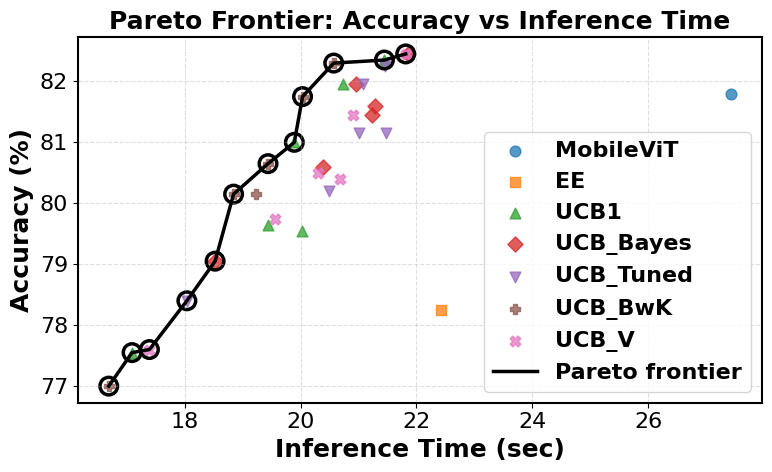

In [ ]:
plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "figure.titlesize": 18,
    "lines.linewidth": 2.5
})

def pareto_front(df):
    df_sorted = df.sort_values("inference_time_sec", ascending=True)
    pareto = []
    best_y = -np.inf
    for _, row in df_sorted.iterrows():
        y = row["accuracy"]
        if y > best_y:
            pareto.append(row)
            best_y = y
    return pd.DataFrame(pareto)

df_phase1 = df[df["variant"] == "phase1"]
families_phase1 = df_phase1["family"].unique()

families = df_phase1["family"].unique()

marker_cycle = [
          "o",
          "s",
          "^",
          "D",
          "v",
          "P",
          "X",
        ]

family_to_marker = {
          fam: marker_cycle[i % len(marker_cycle)]
          for i, fam in enumerate(families)
        }

fig, ax = plt.subplots(figsize=(8, 5))

for fam in families_phase1:
    fam_data = df_phase1[df_phase1["family"] == fam]
    ax.scatter(
        fam_data["inference_time_sec"],
        fam_data["accuracy"],
        marker=family_to_marker[fam],
        s=60,
        alpha=0.75,
        label=fam
    )

pf = pareto_front(df_phase1)

ax.plot(
    pf["inference_time_sec"],
    pf["accuracy"],
    color='black',
    linestyle='-',
    linewidth=2.5,
    label="Pareto frontier"
)

ax.scatter(
    pf["inference_time_sec"],
    pf["accuracy"],
    s=160,
    facecolors='none',
    edgecolors='black',
    linewidth=2.5
)

ax.set_title("Pareto Frontier: Accuracy vs Inference Time", fontweight="bold")
ax.set_xlabel("Inference Time (sec)")
ax.set_ylabel("Accuracy (%)")

ax.grid(True, linestyle="--", alpha=0.4)
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.legend(loc="lower right", frameon=True, prop={"weight": "bold"})

plt.tight_layout()
plt.savefig("menergy_10.1.pdf", dpi=300, bbox_inches="tight")


# Accuracy - Energy tradeoff

In [ ]:
df = con.copy()

def get_family(model_name):
    if "UCB1" in model_name:
        return "UCB1"
    if "UCB_Bayes" in model_name:
        return "UCB_Bayes"
    if "UCB_Tuned" in model_name:
        return "UCB_Tuned"
    if "UCB_V" in model_name:
        return "UCB_V"
    if "UCB_BwK" in model_name:
        return "UCB_BwK"
    if "phase1" in model_name:
        return "EE"
    if "phase2" in model_name:
        return "phase2"
    if "mvit_10" in model_name:
        return "MobileViT"
    if "mvit_100" in model_name:
      return "mvit_100"


def get_variant(model_name):
    if "phase2" in model_name or model_name.startswith("ph2"):
        return "phase2"
    else:
        return "phase1"

df["family"] = df["model_name"].apply(get_family)
df["variant"] = df["model_name"].apply(get_variant)

In [ ]:
df = con.copy()

def get_family(model_name):
    if "UCB1" in model_name: return "UCB1"
    if "UCB_Bayes" in model_name: return "UCB_Bayes"
    if "UCB_Tuned" in model_name: return "UCB_Tuned"
    if "UCB_V" in model_name: return "UCB_V"
    if "UCB_BwK" in model_name: return "UCB_BwK"
    if "phase1" in model_name: return "EE"
    if "phase2" in model_name: return "phase2"
    if "mvit_10" in model_name: return "MobileViT"
    if "mvit_100" in model_name: return "mvit_100"

def get_variant(model_name):
    if "phase2" in model_name or model_name.startswith("ph2"):
        return "phase2"
    else:
        return "phase1"

df["family"] = df["model_name"].apply(get_family)
df["variant"] = df["model_name"].apply(get_variant)

mvit_row = df[df["model_name"] == "mvit_10"]
mvit_phase2 = mvit_row.copy()
mvit_phase2["variant"] = "phase2"
mvit_phase2["family"] = "mvit_10"
df = pd.concat([df, mvit_phase2], ignore_index=True)

def pareto_front(df_sub):
    df_sorted = df_sub.sort_values(["energy_kWh", "accuracy"], ascending=[True, False])
    pareto_points = []
    max_acc = -np.inf
    for _, row in df_sorted.iterrows():
        if row["accuracy"] > max_acc:
            pareto_points.append(row)
            max_acc = row["accuracy"]
    return pd.DataFrame(pareto_points)

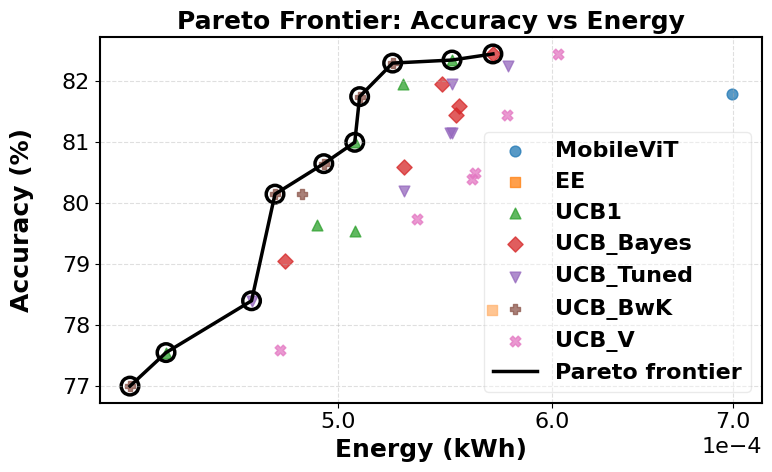

In [ ]:
from matplotlib.ticker import LogLocator, ScalarFormatter

plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "figure.titlesize": 18,
    "lines.linewidth": 2.5
})

def pareto_front(df):
    df_sorted = df.sort_values("energy_kWh", ascending=True)
    pareto = []
    best_y = -np.inf
    for _, row in df_sorted.iterrows():
        y = row["accuracy"]
        if y > best_y:
            pareto.append(row)
            best_y = y
    return pd.DataFrame(pareto)

df_phase1 = df[df["variant"] == "phase1"]
families_phase1 = df_phase1["family"].unique()

families = df_phase1["family"].unique()

marker_cycle = [
          "o",
          "s",
          "^",
          "D",
          "v",
          "P",
          "X",
        ]

family_to_marker = {
          fam: marker_cycle[i % len(marker_cycle)]
          for i, fam in enumerate(families)
        }

fig, ax = plt.subplots(figsize=(8, 5))

for fam in families_phase1:
    fam_data = df_phase1[df_phase1["family"] == fam]
    ax.scatter(
        fam_data["energy_kWh"],
        fam_data["accuracy"],
        marker=family_to_marker[fam],
        s=60,
        alpha=0.75,
        label=fam
    )

pf = pareto_front(df_phase1)

ax.plot(
    pf["energy_kWh"],
    pf["accuracy"],
    color='black',
    linestyle='-',
    linewidth=2.5,
    label="Pareto frontier"
)

ax.scatter(
    pf["energy_kWh"],
    pf["accuracy"],
    s=160,
    facecolors='none',
    edgecolors='black',
    linewidth=2.5
)

ax.set_xscale('log')
ax.xaxis.set_major_locator(LogLocator(base=10.0, subs=None))
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(1, 10)*0.1, numticks=10))
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(axis='x', style='sci', scilimits=(0,0))

ax.set_title("Pareto Frontier: Accuracy vs Energy", fontweight="bold")
ax.set_xlabel("Energy (kWh)")
ax.set_ylabel("Accuracy (%)", labelpad=20)

ax.grid(True, linestyle="--", alpha=0.4)
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.legend(loc="lower right", frameon=True, prop={"weight": "bold"}, framealpha=0.4)

plt.tight_layout()
plt.savefig("ming_10.1.pdf", dpi=300, bbox_inches="tight")